# AerisPlane — Control Surface Analysis

This notebook demonstrates control surface deflections in the VLM solver.
We build a simple wing + horizontal tail aircraft and compare four aileron conditions:

| Case | Right aileron | Left aileron | Expected effect |
|---|---|---|---|
| Neutral | 0° | 0° | Symmetric, Cl = 0 |
| Roll right | +15° (TE-down) | −15° (TE-up) | Negative Cl (roll right) |
| Roll left | −15° (TE-up) | +15° (TE-down) | Positive Cl (roll left) |
| Both down | +15° (TE-down) | +15° (TE-down) | Increased CL, Cl ≈ 0 (like flaps) |

The `ControlSurface.symmetric` flag controls the mirroring behaviour:
- `symmetric=False` — antisymmetric (differential) deflection: right down, left up for positive input
- `symmetric=True`  — symmetric deflection: both sides TE-down together, like a flap

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PolyCollection

import aerisplane as ap
from aerisplane.aero import analyze

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

---
## 1 — Build the aircraft

Simple wing + horizontal tail.  The aileron spans the outer 40 % of each semi-span
and occupies 25 % of the local chord.  `symmetric=False` means it deflects differentially
(right down, left up for positive input).

In [2]:
# Airfoils
naca2412 = ap.Airfoil('naca2412')
naca0009 = ap.Airfoil('naca0009')

# Main wing — tapered, 1.6 m semi-span
# Two surfaces on the same outer span:
#   'aileron'     — antisymmetric (differential roll): right TE-down, left TE-up for +defl
#   'aileron_sym' — symmetric (both TE-down together): acts like a partial flap for +defl
main_wing = ap.Wing(
    name='main_wing',
    xsecs=[
        ap.WingXSec(xyz_le=[0.00, 0.00, 0.00], chord=0.30, twist=2.0, airfoil=naca2412),
        ap.WingXSec(xyz_le=[0.06, 0.80, 0.00], chord=0.22, twist=0.5, airfoil=naca2412),
        ap.WingXSec(xyz_le=[0.10, 1.60, 0.00], chord=0.15, twist=0.0, airfoil=naca2412),
    ],
    symmetric=True,
    control_surfaces=[
        ap.ControlSurface(
            name='aileron',
            span_start=0.60, span_end=1.00,
            chord_fraction=0.25,
            symmetric=False,          # differential: right down, left up for +defl
            max_deflection=25.0,
            min_deflection=-25.0,
        ),
        ap.ControlSurface(
            name='aileron_sym',
            span_start=0.60, span_end=1.00,
            chord_fraction=0.25,
            symmetric=True,           # symmetric: both sides TE-down for +defl
            max_deflection=25.0,
            min_deflection=-25.0,
        ),
    ],
)

# Horizontal tail — symmetric, 0.5 m semi-span
htail = ap.Wing(
    name='htail',
    xsecs=[
        ap.WingXSec(xyz_le=[1.00, 0.00, -0.06], chord=0.14, twist=0.0, airfoil=naca0009),
        ap.WingXSec(xyz_le=[1.04, 0.50, -0.06], chord=0.10, twist=0.0, airfoil=naca0009),
    ],
    symmetric=True,
    control_surfaces=[
        ap.ControlSurface(
            name='elevator',
            span_start=0.0, span_end=1.0,
            chord_fraction=0.35,
            symmetric=True,           # both sides together
        )
    ],
)

aircraft = ap.Aircraft(
    name='WingTail',
    wings=[main_wing, htail],
    xyz_ref=[0.10, 0.0, 0.0],
)

print(f'Reference area:  {aircraft.reference_area():.4f} m²')
print(f'Reference span:  {aircraft.reference_span():.4f} m')
print(f'Reference chord: {aircraft.reference_chord():.4f} m')
print(f'Moment ref:      {aircraft.xyz_ref}')

Reference area:  0.7120 m²
Reference span:  3.2000 m
Reference chord: 0.2352 m
Moment ref:      [0.1, 0.0, 0.0]


---
## 2 — Geometry overview

Saved cs_geometry.png


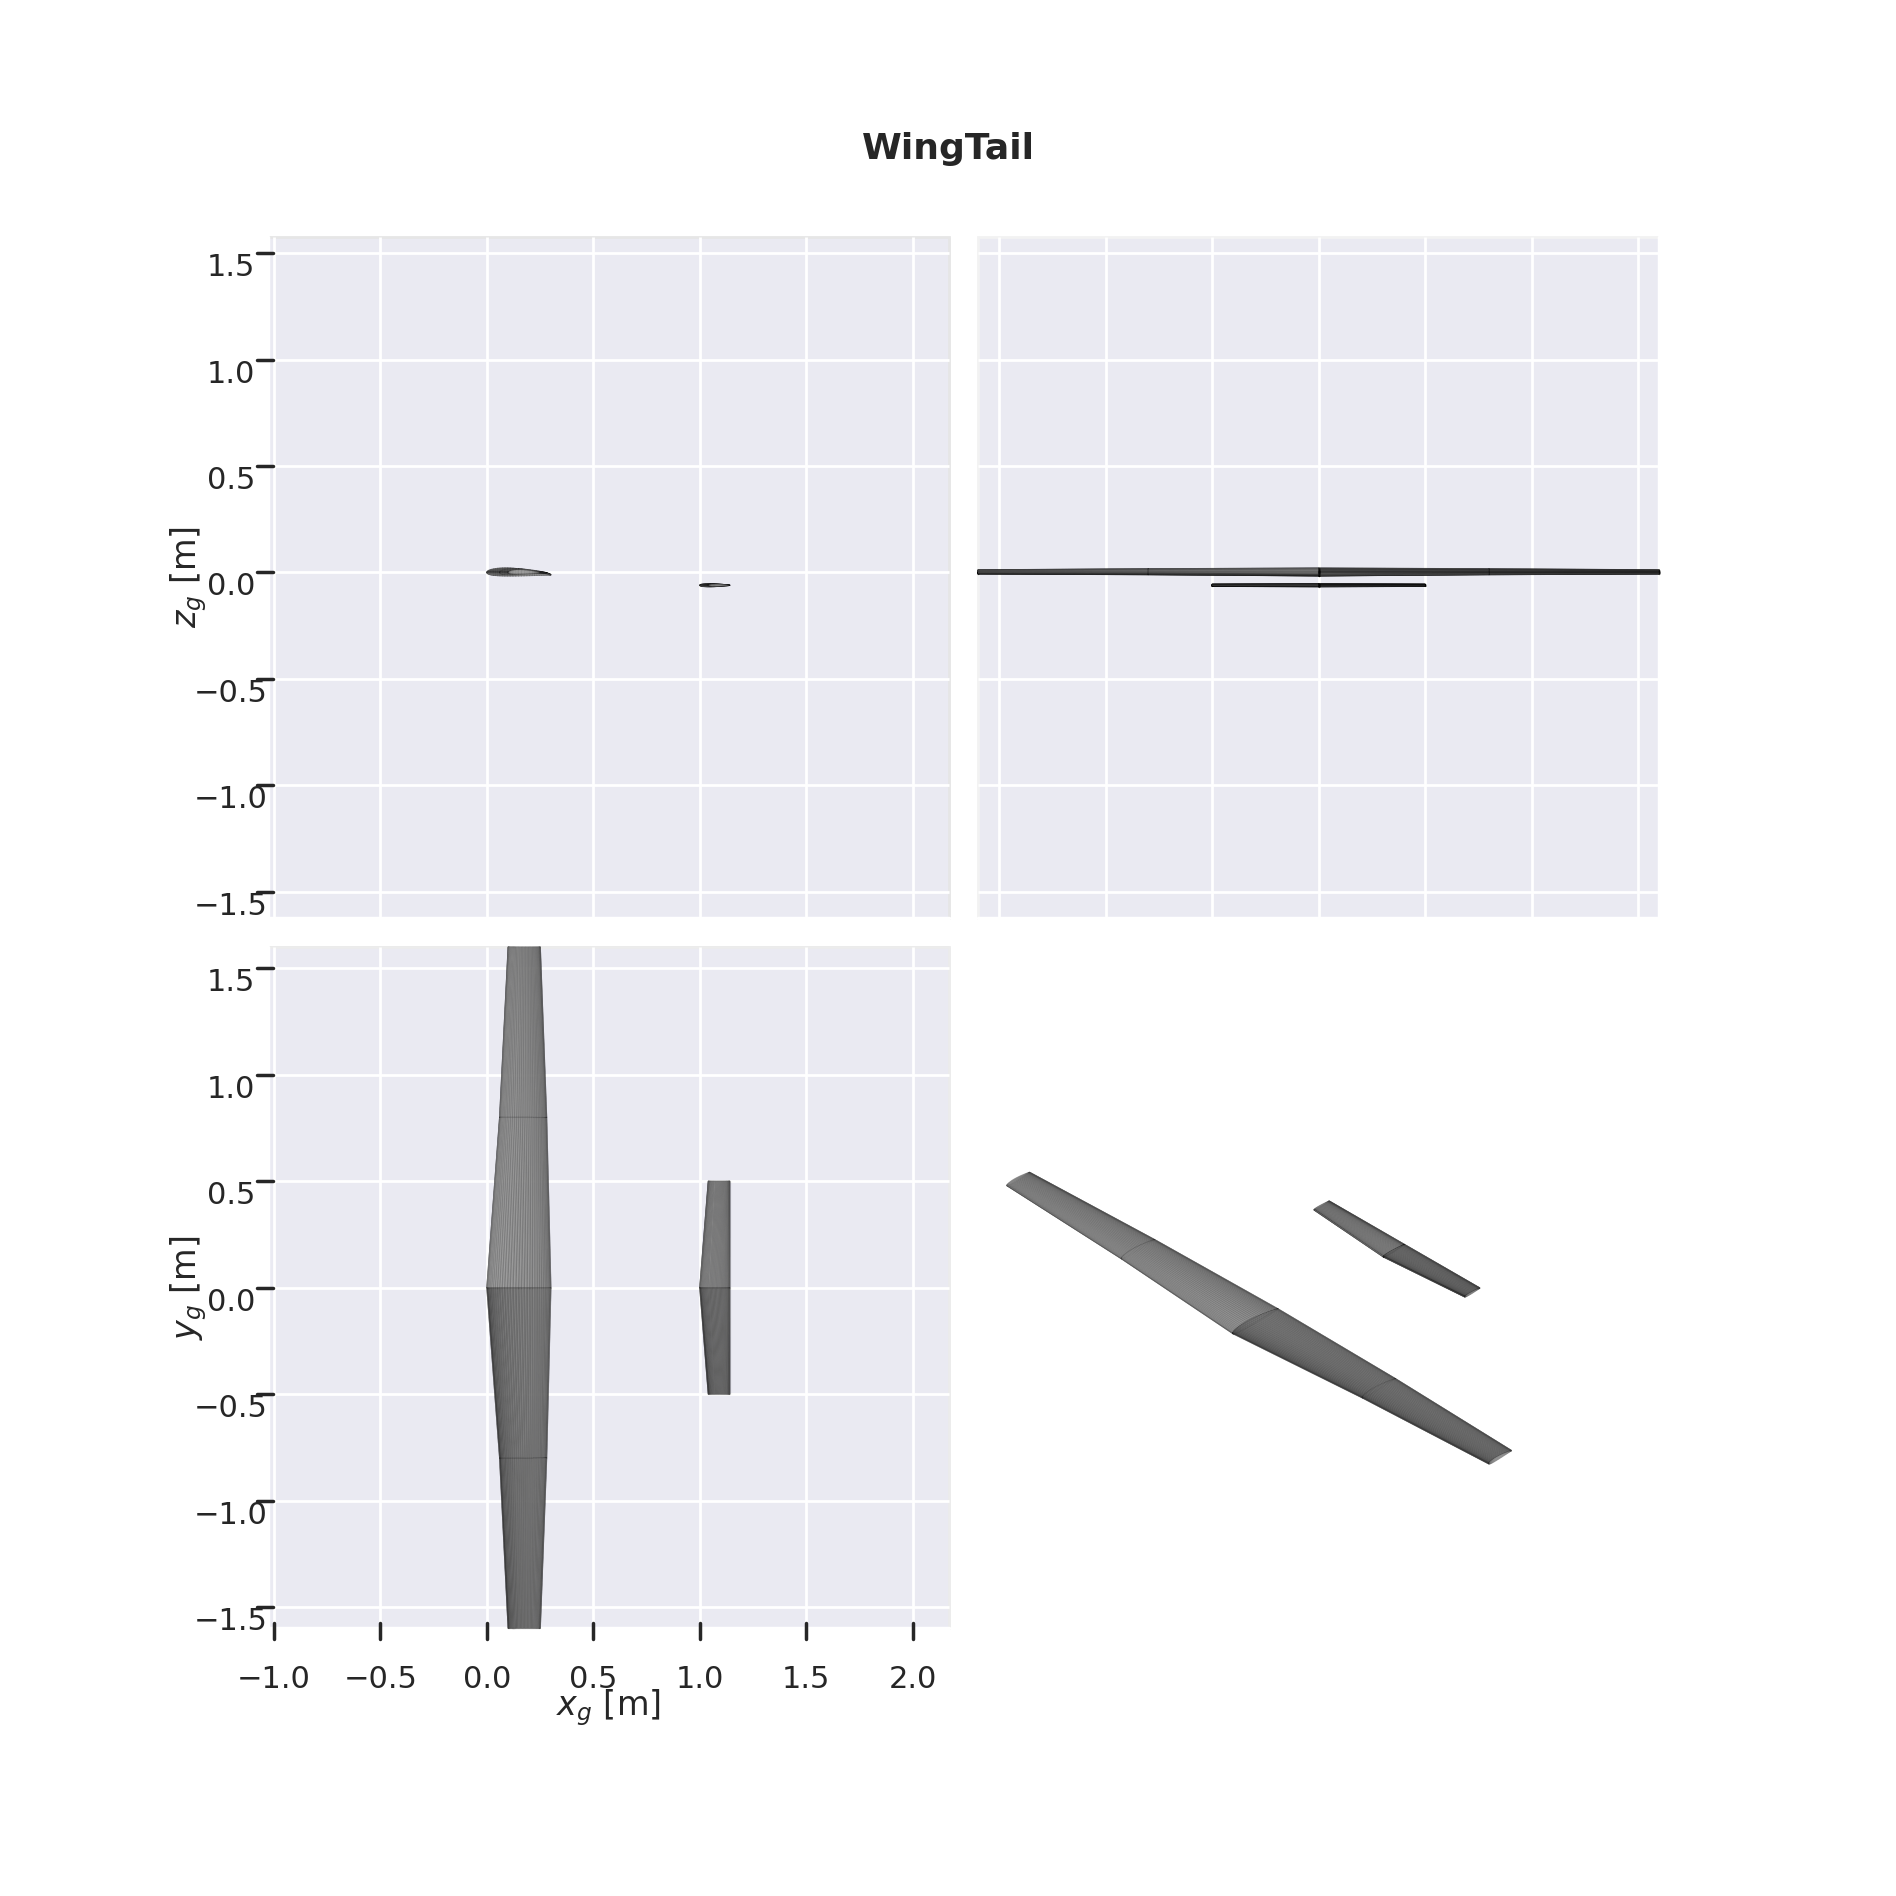

In [3]:
ap.aero.plot_geometry(aircraft=aircraft, style='three_view', show=False,
                      save_path='cs_geometry.png')
print('Saved cs_geometry.png')

---
## 3 — Baseline analysis (no deflection)

Cruise condition: 16 m/s, sea level, α = 4°.

In [4]:
VELOCITY = 16.0   # m/s
ALTITUDE = 0.0    # m (sea level)
ALPHA    = 4.0    # deg

cond_neutral    = ap.FlightCondition(velocity=VELOCITY, altitude=ALTITUDE, alpha=ALPHA)
cond_roll_right = ap.FlightCondition(velocity=VELOCITY, altitude=ALTITUDE, alpha=ALPHA,
                                     deflections={'aileron': +15.0})   # right TE-down, left TE-up
cond_roll_left  = ap.FlightCondition(velocity=VELOCITY, altitude=ALTITUDE, alpha=ALPHA,
                                     deflections={'aileron': -15.0})   # right TE-up, left TE-down
cond_both_down  = ap.FlightCondition(velocity=VELOCITY, altitude=ALTITUDE, alpha=ALPHA,
                                     deflections={'aileron_sym': +15.0})  # both TE-down

KW = dict(method='vlm', spanwise_resolution=8, chordwise_resolution=4)
r_neutral    = analyze(aircraft, cond_neutral,    **KW)
r_roll_right = analyze(aircraft, cond_roll_right, **KW)
r_roll_left  = analyze(aircraft, cond_roll_left,  **KW)
r_both_down  = analyze(aircraft, cond_both_down,  **KW)

cases = {
    'Neutral (0°)':       r_neutral,
    'Roll right (+15°)':  r_roll_right,
    'Roll left (−15°)':   r_roll_left,
    'Both down (+15°)':   r_both_down,
}

print(f"{'Case':<22}  {'CL':>7}  {'CD':>7}  {'Cm':>8}  {'Cl (roll)':>10}")
print('-' * 65)
for name, r in cases.items():
    print(f'{name:<22}  {r.CL:>7.4f}  {r.CD:>7.5f}  {r.Cm:>8.5f}  {r.Cl:>10.6f}')

Case                         CL       CD        Cm   Cl (roll)
-----------------------------------------------------------------
Neutral (0°)             0.6408  0.00926  -0.44594    0.000000
Roll right (+15°)        0.6407  0.01307  -0.44595   -0.057380
Roll left (−15°)         0.6407  0.01307  -0.44595    0.057380
Both down (+15°)         0.8057  0.01704  -0.57772   -0.000000


---
## 4 — Alpha sweep: CL and rolling moment vs. α

Sweep α from −4° to 14° for all three aileron settings.

In [5]:
ALPHAS = np.linspace(-4, 14, 10)

deflections_map = {
    'Neutral (0°)':      {},
    'Roll right (+15°)': {'aileron':     +15.0},
    'Roll left (−15°)':  {'aileron':     -15.0},
    'Both down (+15°)':  {'aileron_sym': +15.0},
}
COLORS  = ['#546E7A', '#E53935', '#1E88E5', '#43A047']
LSTYLES = ['-', '--', ':', '-.']
MARKERS = ['o', 's', '^', 'D']

polars = {label: [] for label in deflections_map}

for label, defl in deflections_map.items():
    for alpha in ALPHAS:
        cond = ap.FlightCondition(
            velocity=VELOCITY, altitude=ALTITUDE,
            alpha=float(alpha), deflections=defl,
        )
        polars[label].append(
            analyze(aircraft, cond, method='vlm',
                    spanwise_resolution=8, chordwise_resolution=4)
        )

print(f'Sweep done: {len(ALPHAS)} points × {len(deflections_map)} cases = {len(ALPHAS)*len(deflections_map)} solves')

Sweep done: 10 points × 4 cases = 40 solves


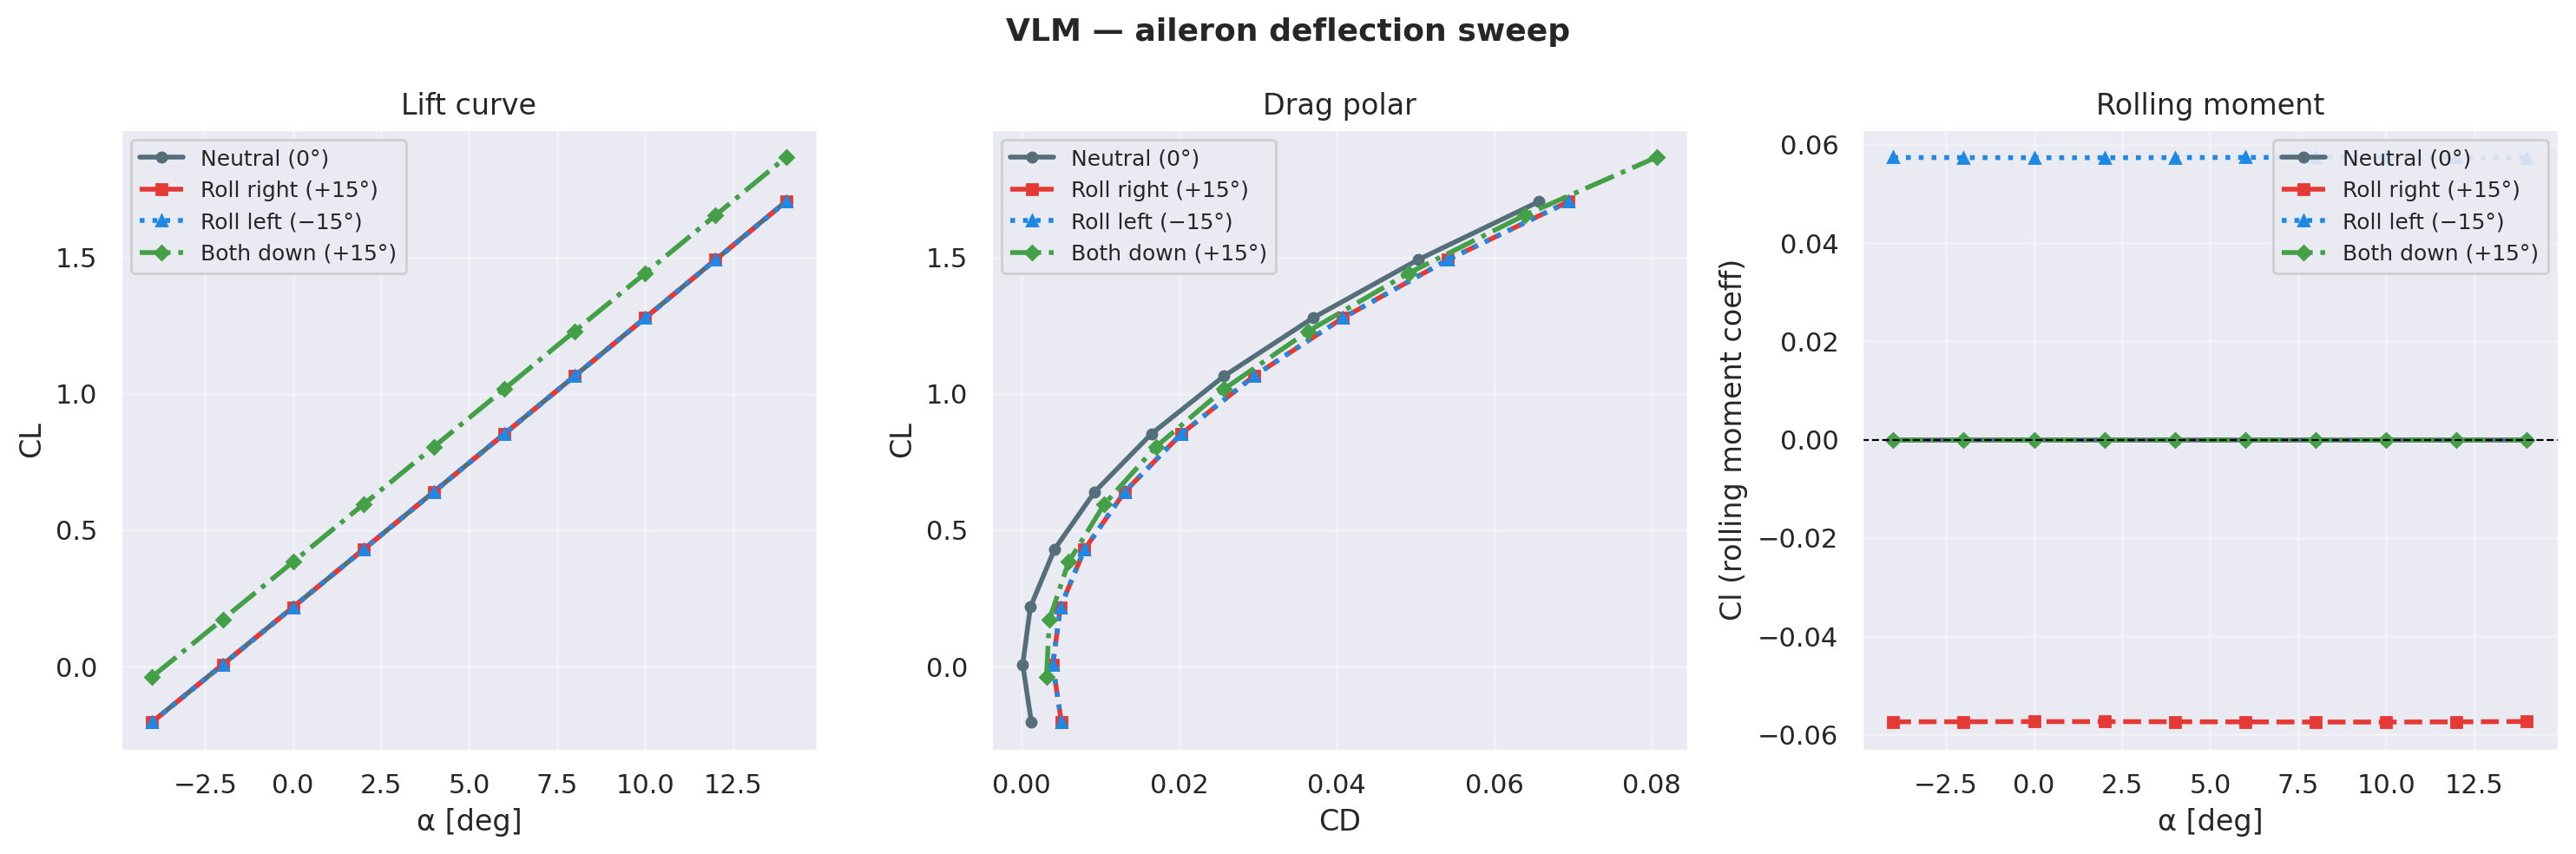

Saved cs_sweep.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('VLM — aileron deflection sweep', fontsize=13, fontweight='bold')

for (label, results), color, ls, mk in zip(polars.items(), COLORS, LSTYLES, MARKERS):
    CLs = [r.CL for r in results]
    CDs = [r.CD for r in results]
    Cls = [r.Cl for r in results]

    axes[0].plot(ALPHAS, CLs, color=color, ls=ls, lw=2.0, marker=mk, ms=4, label=label)
    axes[1].plot(CDs,   CLs, color=color, ls=ls, lw=2.0, marker=mk, ms=4, label=label)
    axes[2].plot(ALPHAS, Cls, color=color, ls=ls, lw=2.0, marker=mk, ms=4, label=label)

axes[0].set_xlabel('α [deg]'); axes[0].set_ylabel('CL'); axes[0].set_title('Lift curve')
axes[1].set_xlabel('CD');      axes[1].set_ylabel('CL'); axes[1].set_title('Drag polar')
axes[2].set_xlabel('α [deg]'); axes[2].set_ylabel('Cl (rolling moment coeff)')
axes[2].set_title('Rolling moment')
axes[2].axhline(0, color='k', lw=0.8, ls='--')

for ax in axes:
    ax.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('cs_sweep.png', bbox_inches='tight')
plt.show()
print('Saved cs_sweep.png')

---
## 5 — Deflection sweep at fixed α

Hold α = 4° and sweep aileron deflection from −20° to +20°.
Shows that Cl scales linearly with deflection (inviscid VLM) and that
CL and Cm change symmetrically.

In [7]:
DEFLECTIONS = np.linspace(-20, 20, 17)

defl_results = []
for defl in DEFLECTIONS:
    cond = ap.FlightCondition(
        velocity=VELOCITY, altitude=ALTITUDE, alpha=ALPHA,
        deflections={'aileron': float(defl)},
    )
    defl_results.append(
        analyze(aircraft, cond, method='vlm',
                spanwise_resolution=8, chordwise_resolution=4)
    )

CLs_d  = [r.CL for r in defl_results]
CDs_d  = [r.CD for r in defl_results]
Cls_d  = [r.Cl for r in defl_results]
Cms_d  = [r.Cm for r in defl_results]

# Rolling-moment effectiveness: dCl/d(aileron) [1/deg]
Clda = float(np.polyfit(DEFLECTIONS, Cls_d, 1)[0])
print(f'Roll authority  Cl_δa = {Clda:.5f} /deg')
print(f'  → at δa = ±15°: ΔCl ≈ ±{abs(Clda)*15:.4f}')

Roll authority  Cl_δa = -0.00382 /deg
  → at δa = ±15°: ΔCl ≈ ±0.0574


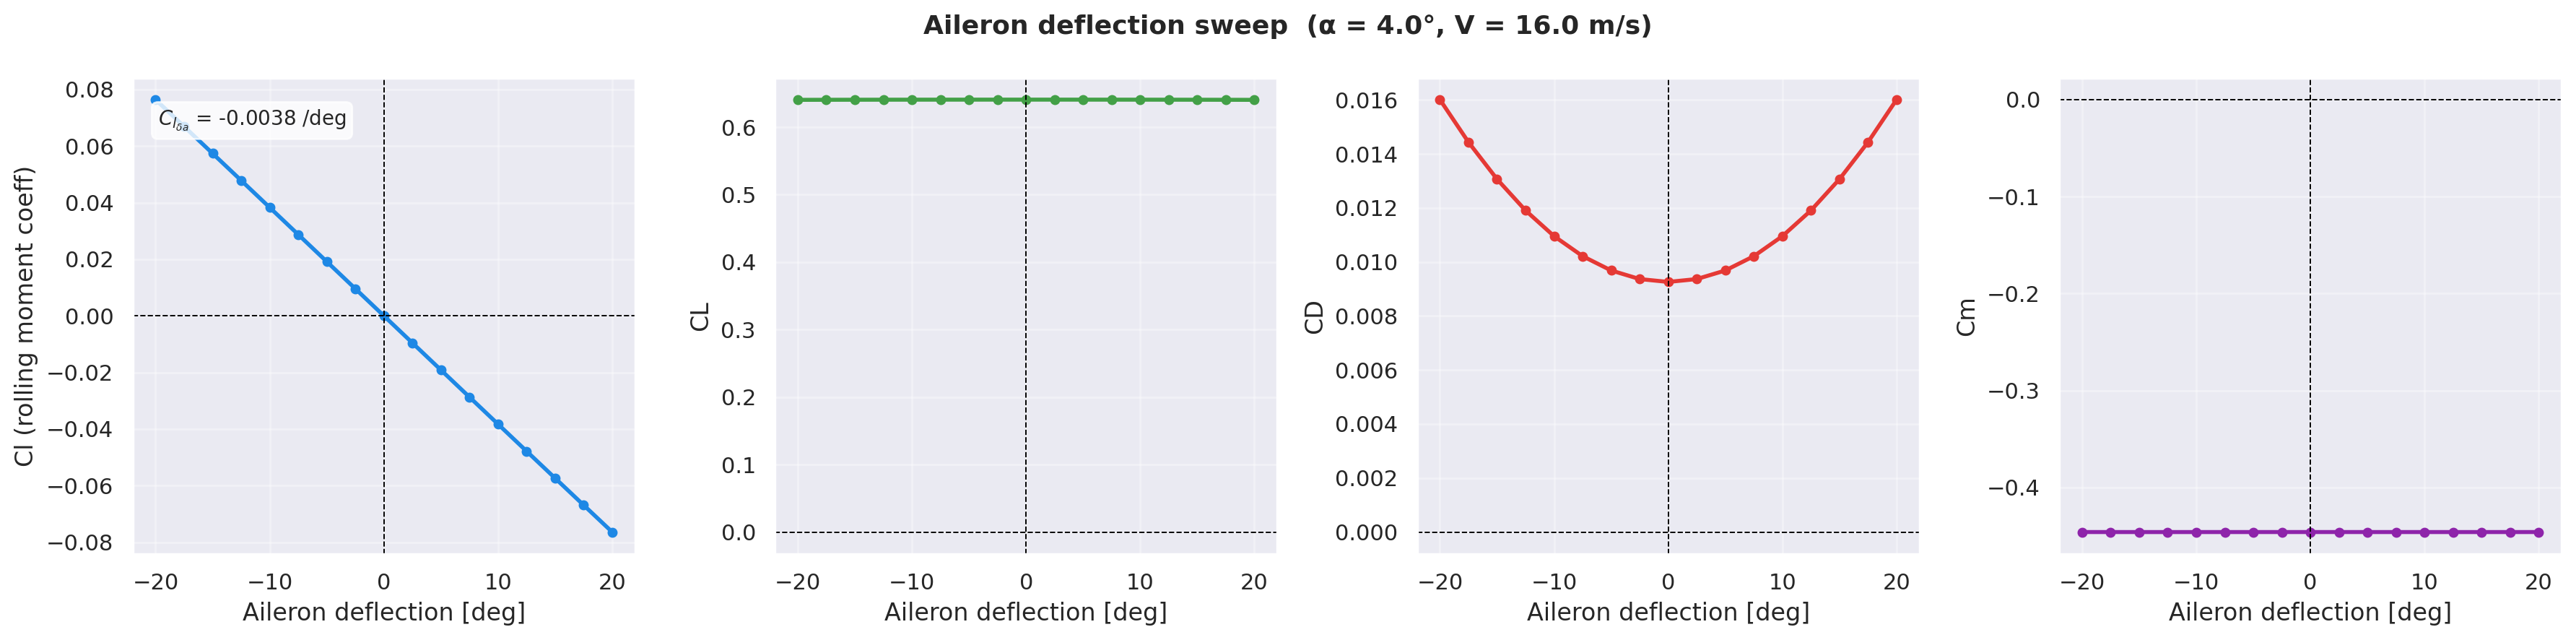

Saved cs_defl_sweep.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle(f'Aileron deflection sweep  (α = {ALPHA}°, V = {VELOCITY} m/s)',
             fontsize=13, fontweight='bold')

data = [
    (Cls_d, 'Cl (rolling moment coeff)', '#1E88E5'),
    (CLs_d, 'CL',                        '#43A047'),
    (CDs_d, 'CD',                        '#E53935'),
    (Cms_d, 'Cm',                        '#8E24AA'),
]
for ax, (vals, ylabel, color) in zip(axes, data):
    ax.plot(DEFLECTIONS, vals, color=color, lw=2.0, marker='o', ms=4)
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.axvline(0, color='k', lw=0.7, ls='--')
    ax.set_xlabel('Aileron deflection [deg]')
    ax.set_ylabel(ylabel)

# Annotate Cl_delta_a
axes[0].annotate(
    f'$C_{{l_{{\\delta a}}}}$ = {Clda:.4f} /deg',
    xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
)

plt.tight_layout()
plt.savefig('cs_defl_sweep.png', bbox_inches='tight')
plt.show()
print('Saved cs_defl_sweep.png')

---
## 6 — Spanwise Cl distribution

Compare spanwise lift loading for neutral, roll-right, and both-down deflections.
Each wing surface is plotted as a **separate line** with the same colour per case:
solid = main wing, dashed = horizontal tail.

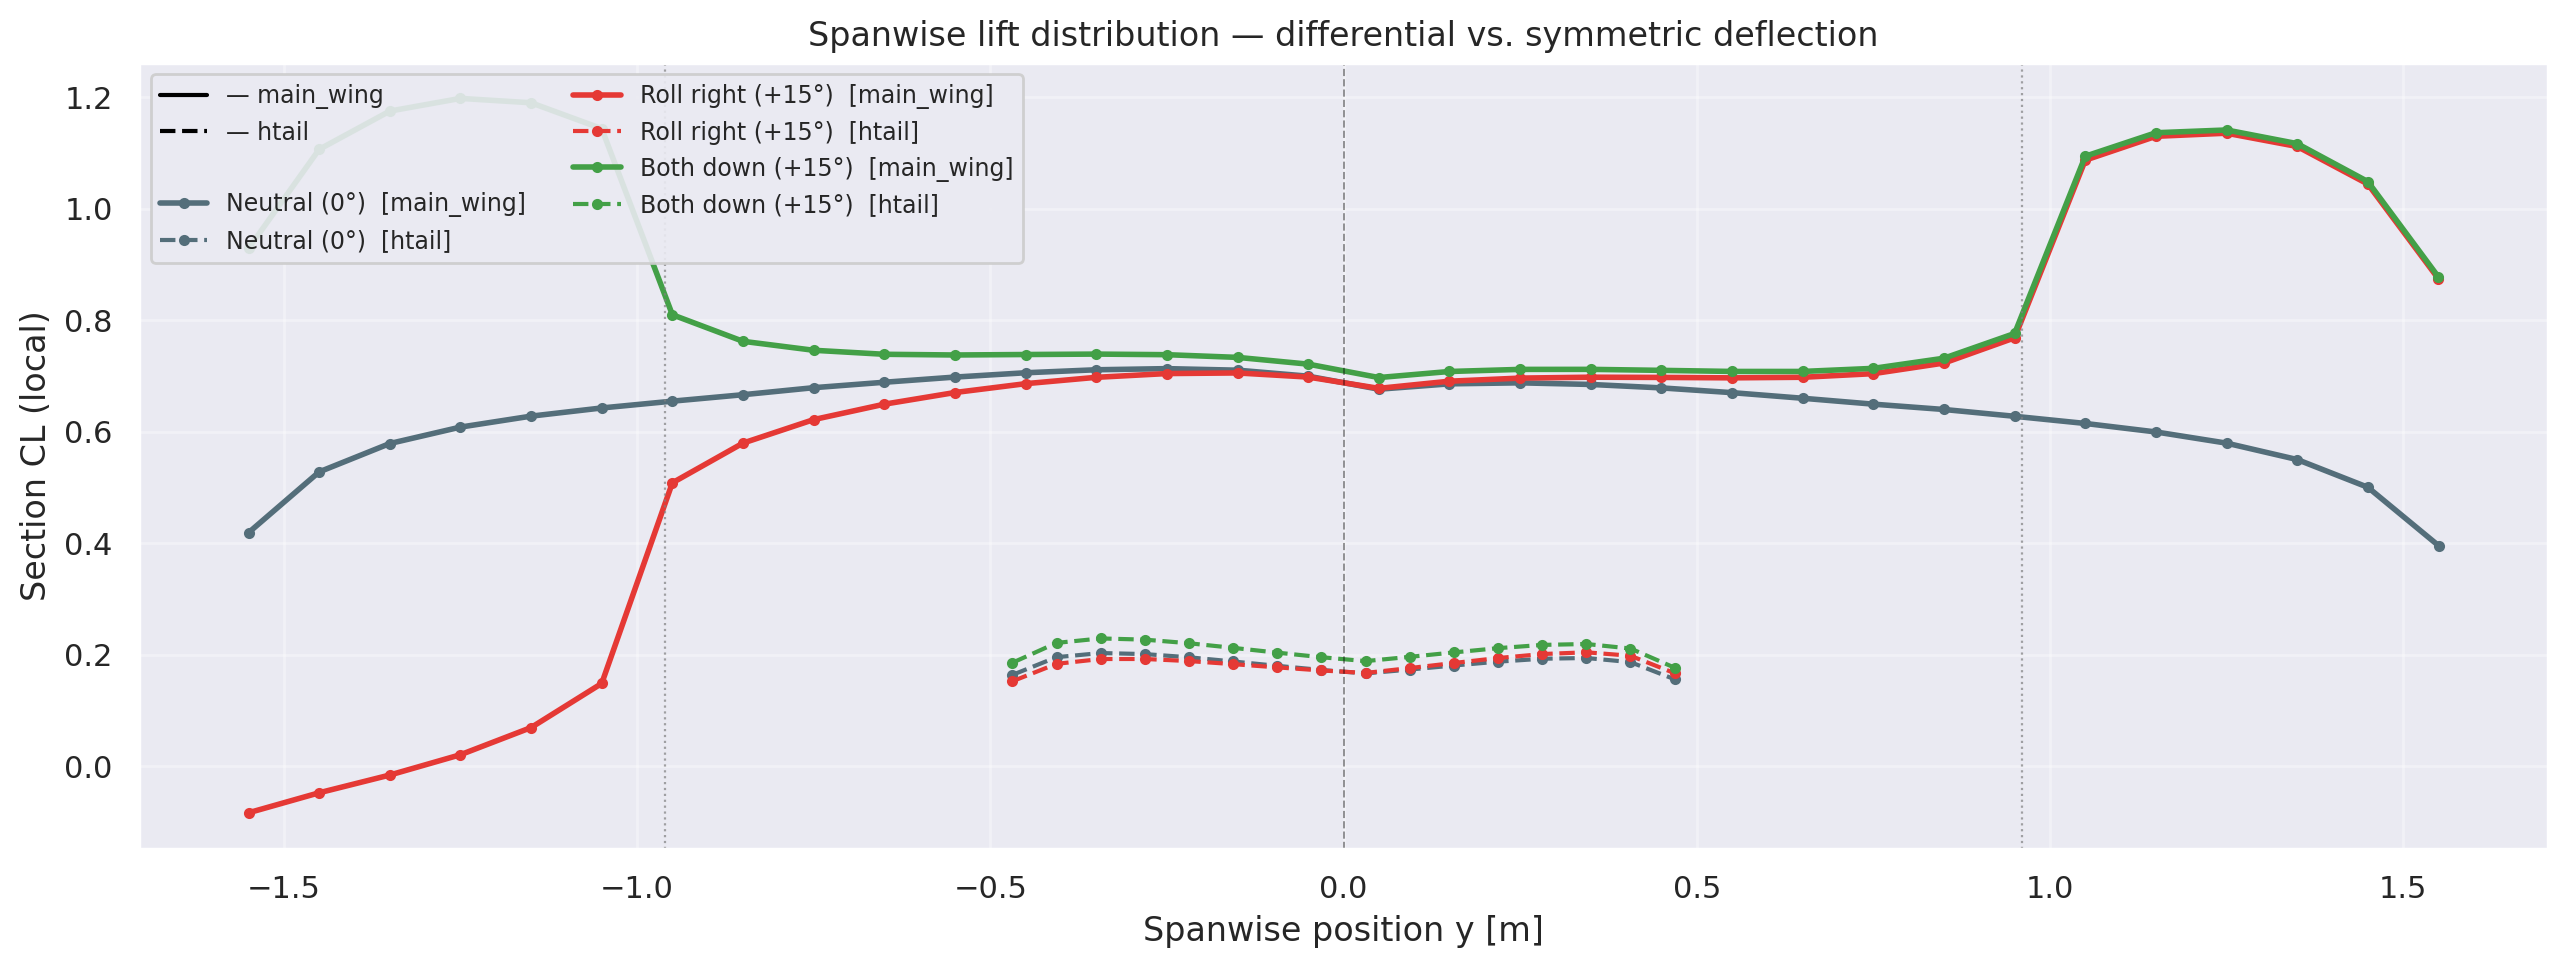

Saved cs_spanwise.png


In [9]:
def extract_spanwise_cl_by_wing(result):
    """Return {wing_name: (y_sorted, cl_sorted)} for each wing separately."""
    vlm = result._solver
    y_all     = 0.5 * (vlm.left_vortex_vertices[:, 1] + vlm.right_vortex_vertices[:, 1])
    chord_vec = vlm.back_left_vertices - vlm.front_left_vertices
    chords    = np.linalg.norm(chord_vec, axis=1)
    cl_local  = 2.0 * vlm.vortex_strengths / (result.velocity * chords)
    N         = vlm.chordwise_resolution

    wing_data = {}
    for rec in vlm.wing_records:
        s   = rec['panel_start']
        n   = rec['n_panels']
        y_w = y_all[s:s + n]
        cl_w = cl_local[s:s + n]

        # Average over chordwise panels within each spanwise strip
        n_strips = n // N
        y_bins  = np.array([y_w [i*N:(i+1)*N].mean() for i in range(n_strips)])
        cl_bins = np.array([cl_w[i*N:(i+1)*N].mean() for i in range(n_strips)])

        order = np.argsort(y_bins)
        wing_data[rec['wing'].name] = (y_bins[order], cl_bins[order])

    return wing_data

# Cases to plot on spanwise graph
span_cases = {
    'Neutral (0°)':      r_neutral,
    'Roll right (+15°)': r_roll_right,
    'Both down (+15°)':  r_both_down,
}
span_colors = ['#546E7A', '#E53935', '#43A047']

# Line styles by surface order: first wing = solid, subsequent = dashed, dotted, …
SURFACE_STYLES = ['-', '--', ':', '-.']

fig, ax = plt.subplots(figsize=(13, 5))

legend_handles = []
for (case_label, result), color in zip(span_cases.items(), span_colors):
    wing_data = extract_spanwise_cl_by_wing(result)
    for surface_idx, (wing_name, (y_arr, cl_arr)) in enumerate(wing_data.items()):
        ls = SURFACE_STYLES[surface_idx]
        lw = 2.0 if surface_idx == 0 else 1.5
        line, = ax.plot(y_arr, cl_arr, color=color, ls=ls, lw=lw, marker='o', ms=3)
        legend_handles.append((line, f'{case_label}  [{wing_name}]'))

# Vertical markers for aileron start
ax.axvline( 0.60 * 1.60, color='grey', lw=0.8, ls=':', alpha=0.7)
ax.axvline(-0.60 * 1.60, color='grey', lw=0.8, ls=':', alpha=0.7,
           label='Aileron start (60 % span)')
ax.axvline(0, color='k', lw=0.7, ls='--', alpha=0.4)

# Build legend: group by wing surface (all main_wing entries, then all htail entries)
wing_names = list(list(extract_spanwise_cl_by_wing(r_neutral).keys()))
grouped_handles = []
for wing_name in wing_names:
    grouped_handles.append(
        plt.Line2D([0], [0], color='k',
                   ls=SURFACE_STYLES[wing_names.index(wing_name)], lw=1.5,
                   label=f'— {wing_name}')
    )
grouped_handles.append(plt.Line2D([0], [0], color='none', label=''))  # spacer

for (line, label) in legend_handles:
    grouped_handles.append(
        plt.Line2D([0], [0], color=line.get_color(),
                   ls=line.get_linestyle(), lw=line.get_linewidth(),
                   marker='o', ms=3, label=label)
    )

ax.legend(handles=grouped_handles, fontsize=8.5, framealpha=0.9,
          ncol=2, loc='upper left')
ax.set_xlabel('Spanwise position y [m]')
ax.set_ylabel('Section CL (local)')
ax.set_title('Spanwise lift distribution — differential vs. symmetric deflection')
plt.tight_layout()
plt.savefig('cs_spanwise.png', bbox_inches='tight')
plt.show()
print('Saved cs_spanwise.png')

---
## 7 — Panel mesh visualisation

Top-down view of the VLM panel mesh, coloured by vortex strength γ.
The asymmetry in γ between the left and right ailerons is clearly visible.

/tmp/ipykernel_111967/3055213293.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


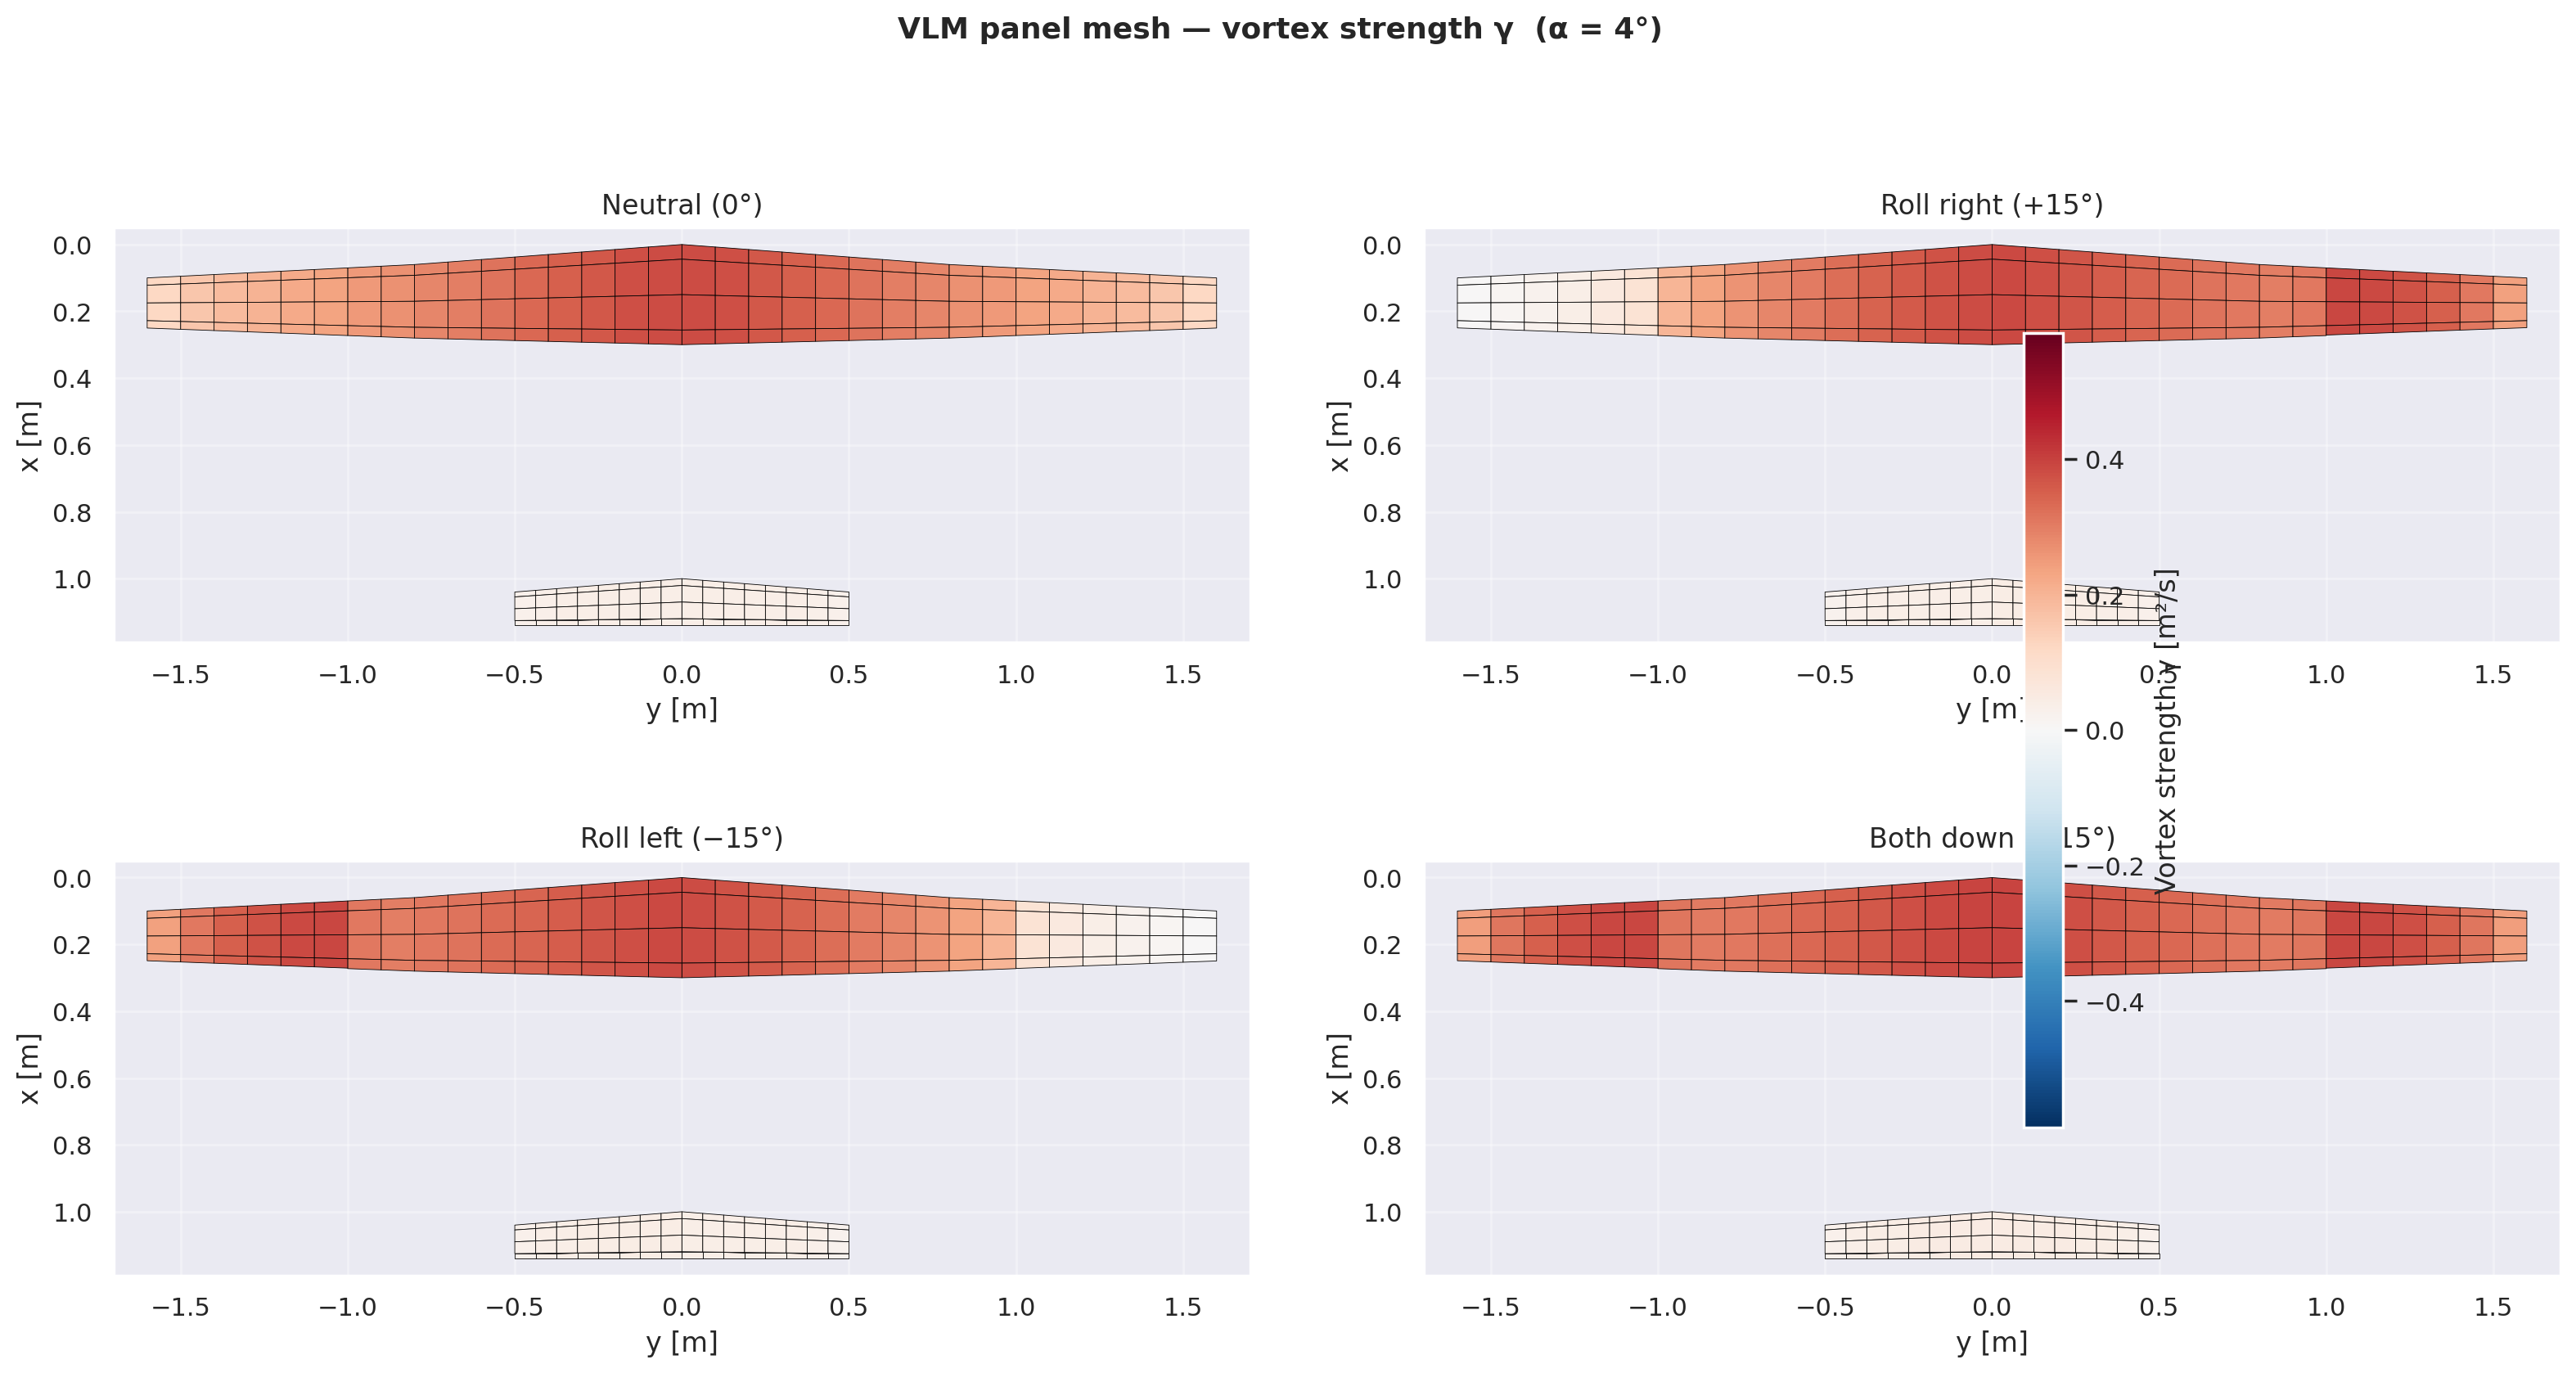

Saved cs_mesh.png


In [10]:
def plot_panel_mesh(result, title, ax, cmap='RdBu_r', clim=None):
    vlm = result._solver
    fl = vlm.front_left_vertices
    bl = vlm.back_left_vertices
    br = vlm.back_right_vertices
    fr = vlm.front_right_vertices
    gamma = vlm.vortex_strengths

    N = vlm.chordwise_resolution
    n_strips = len(gamma) // N
    gamma_per_panel = np.repeat(
        np.array([gamma[i*N:(i+1)*N].mean() for i in range(n_strips)]), N,
    )
    verts = np.stack([fl, bl, br, fr], axis=1)[:, :, [0, 1]]
    if clim is None:
        vmax = np.max(np.abs(gamma_per_panel))
        clim = (-vmax, vmax)
    col = PolyCollection(verts[:, :, [1, 0]], array=gamma_per_panel,
                         cmap=cmap, edgecolors='k', linewidths=0.3)
    col.set_clim(*clim)
    ax.add_collection(col)
    ax.set_xlim(np.min(fl[:, 1]) - 0.1, np.max(fr[:, 1]) + 0.1)
    ax.set_ylim(np.min(fl[:, 0]) - 0.05, np.max(bl[:, 0]) + 0.05)
    ax.set_xlabel('y [m]'); ax.set_ylabel('x [m]')
    ax.set_title(title); ax.set_aspect('equal'); ax.invert_yaxis()
    return col

fig, axes_grid = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('VLM panel mesh — vortex strength γ  (α = 4°)', fontsize=13, fontweight='bold')
axes_list = list(axes_grid.flat)

all_gamma = np.concatenate([r._solver.vortex_strengths for r in cases.values()])
vmax = np.max(np.abs(all_gamma))
clim = (-vmax, vmax)

for ax, (label, result) in zip(axes_list, cases.items()):
    col = plot_panel_mesh(result, label, ax, clim=clim)

fig.colorbar(col, ax=axes_list, label='Vortex strength γ [m²/s]', shrink=0.7, pad=0.02)
plt.tight_layout()
plt.savefig('cs_mesh.png', bbox_inches='tight')
plt.show()
print('Saved cs_mesh.png')

---
## 8 — Summary table

In [11]:
r_ref = r_neutral

print(f"{'Case':<22}  {'CL':>7}  {'CD':>8}  {'Cm':>8}  {'Cl':>9}  {'ΔCL':>8}  {'ΔCl':>9}")
print('─' * 82)
for name, r in cases.items():
    dCL = r.CL - r_ref.CL
    dCl = r.Cl - r_ref.Cl
    print(f'{name:<22}  {r.CL:>7.4f}  {r.CD:>8.5f}  {r.Cm:>8.5f}  {r.Cl:>9.5f}  {dCL:>+8.4f}  {dCl:>+9.5f}')

print()
print(f'Roll authority (differential):  Cl_δa = {Clda:.5f} per deg')
print(f'  → at δa = ±15°:  ΔCl = ±{abs(Clda)*15:.4f}')
print()
print('Key differences between symmetric and antisymmetric deflection:')
dCL_sym = r_both_down.CL - r_neutral.CL
dCm_sym = r_both_down.Cm - r_neutral.Cm
dCL_dif = r_roll_right.CL - r_neutral.CL
print(f'  Symmetric (+15°, both down):  ΔCL = {dCL_sym:+.4f},  ΔCm = {dCm_sym:+.5f},  ΔCl ≈ 0')
print(f'  Differential (+15°, roll R):  ΔCL = {dCL_dif:+.4f},  ΔCm ≈ 0,         ΔCl = {r_roll_right.Cl:+.5f}')
print()
print('Observations:')
print('  • Differential deflection: Cl ≠ 0 (rolls the aircraft), CL and Cm unchanged.')
print('  • Symmetric deflection:    Cl ≈ 0 (no roll), CL increases (extra lift), Cm changes.')
print('  • Both cases increase CD — profile drag from the deflected surface.')

Case                         CL        CD        Cm         Cl       ΔCL        ΔCl
──────────────────────────────────────────────────────────────────────────────────
Neutral (0°)             0.6408   0.00926  -0.44594    0.00000   +0.0000   +0.00000
Roll right (+15°)        0.6407   0.01307  -0.44595   -0.05738   -0.0002   -0.05738
Roll left (−15°)         0.6407   0.01307  -0.44595    0.05738   -0.0002   +0.05738
Both down (+15°)         0.8057   0.01704  -0.57772   -0.00000   +0.1649   -0.00000

Roll authority (differential):  Cl_δa = -0.00382 per deg
  → at δa = ±15°:  ΔCl = ±0.0574

Key differences between symmetric and antisymmetric deflection:
  Symmetric (+15°, both down):  ΔCL = +0.1649,  ΔCm = -0.13178,  ΔCl ≈ 0
  Differential (+15°, roll R):  ΔCL = -0.0002,  ΔCm ≈ 0,         ΔCl = -0.05738

Observations:
  • Differential deflection: Cl ≠ 0 (rolls the aircraft), CL and Cm unchanged.
  • Symmetric deflection:    Cl ≈ 0 (no roll), CL increases (extra lift), Cm changes.
  • Both